<a href="https://colab.research.google.com/github/alejandrajimenez360-dot/GEIH/blob/main/Modelos_GEIH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de la base de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# La ruta exacta donde dejaste el archivo consolidado
RUTA_BASE = '/content/drive/MyDrive/Maestria_IA/TFM/Datos/df_consolidado_2025.csv'

# Leer el archivo de forma directa
df_consolidado_2025 = pd.read_csv(RUTA_BASE, low_memory=False)

print("¡Base de datos cargada con éxito!")
print(f"Dimensiones: {df_consolidado_2025.shape[0]} filas y {df_consolidado_2025.shape[1]} columnas.")

¡Base de datos cargada con éxito!
Dimensiones: 399316 filas y 71 columnas.


In [ ]:
# Ver las primeras 5 filas
display(df_consolidado_2025.head())

# Verificar que tu variable objetivo esté intacta
print("\nDistribución del Estado Laboral:")
print(df_consolidado_2025['Estado_Laboral'].value_counts(dropna=False))

,DIRECTORIO,SECUENCIA_P,HOGAR,Tipo_Vivienda,Energia_Electrica,Estrato,Gas,Alcantarillado,Acueducto,N_Hogares,...,RAMA4D_R4,Desocupado_Sin_Ingreso,Tiempo_Desempleo_Meses,Oficio_ult_Trabajo,Tamaño_Empresa_Ant,desempleo,Informalidad_Final,Estado_Laboral,jefe_Hogar,Tiene_Discapacidad
0,8173631,1,1,1,1,1.0,1,2,1,1,...,5619.0,NaN,NaN,NaN,NaN,0.0,1.0,Ocupado Informal,1,0
1,8173631,1,1,1,1,1.0,1,2,1,1,...,4541.0,NaN,NaN,NaN,NaN,0.0,1.0,Ocupado Informal,0,0
2,8173632,1,1,1,1,1.0,1,2,1,1,...,3110.0,NaN,NaN,NaN,NaN,0.0,1.0,Ocupado Informal,1,0
3,8173633,1,1,1,1,1.0,1,2,1,1,...,161.0,NaN,NaN,NaN,NaN,0.0,1.0,Ocupado Informal,0,0
4,8173633,1,1,1,1,1.0,1,2,1,1,...,5619.0,NaN,NaN,NaN,NaN,0.0,1.0,Ocupado Informal,0,0



Distribución del Estado Laboral:
Estado_Laboral
Ocupado Informal    236688
Ocupado Formal      121341
Desocupado           41287
Name: count, dtype: int64


In [ ]:
df_consolidado_2025.columns.tolist()

['DIRECTORIO',
 'SECUENCIA_P',
 'HOGAR',
 'Tipo_Vivienda',
 'Energia_Electrica',
 'Estrato',
 'Gas',
 'Alcantarillado',
 'Acueducto',
 'N_Hogares',
 'N_Habitaciones',
 'N_Habs_Dormir',
 'Regimen_Propiedad',
 'Valor_Cuota',
 'Valor_Arriendo',
 'N_Personas_Hogar',
 'MES',
 'PER',
 'ORDEN',
 'Zona',
 'FEX_C18',
 'AREA',
 'Sexo',
 'Edad',
 'Parentesco_Jefe_Hogar',
 'Campesino',
 'Etnia',
 'Estado_Civil',
 'EPS',
 'Regimen_EPS',
 'Paga_Pension',
 'Disc_Oir',
 'Disc_Hablar',
 'Disc_Ver',
 'Disc_Movimiento',
 'Disc_Agarrar_manos',
 'Disc_Decisiones',
 'Disc_Comer',
 'Disc_Interaccion',
 'Sabe_leer_Escribir',
 'Actualmente_Estudia',
 'Tipo_Institucion',
 'Escolaridad',
 'Fuerza_Trabajo',
 'Fuera_Fuerza_Trabajo',
 'Poblacion_Edad_Trabajo',
 'Contrato',
 'Tipo_Contrato',
 'Termino_Contrato',
 'Cargo_Actual_Cod',
 'Camara_Comercio',
 'Ruth',
 'Personeria_Juridica',
 'Sueldo',
 'N_empleados',
 'Cotiza_Pension',
 'Fondo_Pension',
 'Quien_Paga_Pension',
 'ARL',
 'OCI',
 'Ingresos',
 'RAMA4D_R4',
 'D

## Validación de balanceo entre clases

In [ ]:
# Conteo absoluto y porcentual del target
conteo_clases = df_consolidado_2025['Estado_Laboral'].value_counts()
porcentaje_clases = df_consolidado_2025['Estado_Laboral'].value_counts(normalize=True) * 100

reporte_balance = pd.DataFrame({
    'Casos (Cantidad)': conteo_clases,
    'Proporción (%)': porcentaje_clases
})

print("=== BALANCE DE LA VARIABLE OBJETIVO (TARGET) ===")
print(reporte_balance.round(2))

=== BALANCE DE LA VARIABLE OBJETIVO (TARGET) ===
                  Casos (Cantidad)  Proporción (%)
Estado_Laboral                                    
Ocupado Informal            236688           59.27
Ocupado Formal              121341           30.39
Desocupado                   41287           10.34


# **Pruebas previas al modelado**

## Selección de Variables con Regresión Lasso


In [ ]:
print(df_consolidado_2025.columns.tolist())

['DIRECTORIO', 'SECUENCIA_P', 'HOGAR', 'Tipo_Vivienda', 'Energia_Electrica', 'Estrato', 'Gas', 'Alcantarillado', 'Acueducto', 'N_Hogares', 'N_Habitaciones', 'N_Habs_Dormir', 'Regimen_Propiedad', 'Valor_Cuota', 'Valor_Arriendo', 'N_Personas_Hogar', 'MES', 'PER', 'ORDEN', 'Zona', 'FEX_C18', 'AREA', 'Sexo', 'Edad', 'Parentesco_Jefe_Hogar', 'Campesino', 'Etnia', 'Estado_Civil', 'EPS', 'Regimen_EPS', 'Paga_Pension', 'Disc_Oir', 'Disc_Hablar', 'Disc_Ver', 'Disc_Movimiento', 'Disc_Agarrar_manos', 'Disc_Decisiones', 'Disc_Comer', 'Disc_Interaccion', 'Sabe_leer_Escribir', 'Actualmente_Estudia', 'Tipo_Institucion', 'Escolaridad', 'Fuerza_Trabajo', 'Fuera_Fuerza_Trabajo', 'Poblacion_Edad_Trabajo', 'Contrato', 'Tipo_Contrato', 'Termino_Contrato', 'Cargo_Actual_Cod', 'Camara_Comercio', 'Ruth', 'Personeria_Juridica', 'Sueldo', 'N_empleados', 'Cotiza_Pension', 'Fondo_Pension', 'Quien_Paga_Pension', 'ARL', 'OCI', 'Ingresos', 'RAMA4D_R4', 'Desocupado_Sin_Ingreso', 'Tiempo_Desempleo_Meses', 'Oficio_ult_

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# 1. Hacemos una copia fresca de los datos consolidados

df_lasso_prep = df_consolidado_2025.copy()

# ==============================================================================
# 2. DEFINICIÓN DE LISTAS DE VARIABLES PURAS (SOCIODEMOGRÁFICAS SIN FUGA)
# ==============================================================================

# Incluimos Edad y Año_Grado como continuas/ordinales
variables_continuas = ['Edad']

# Incluimos Escolaridad (liberada de endogeneidad gracias al árbol de asalariados)
# Quedan EXCLUIDAS estrictamente las de salud, pensión y contrato por ser el flujo definidor:
# Regimen_EPS (P6100), Paga_Pension (P6110), Tipo_Contrato (P6450), Cotiza_Pension (P6920) y Fondo_Pension (P6930).

variables_categoricas = [
    'AREA', 'Sexo', 'Campesino', 'Etnia', 'Estado_Civil', 'Escolaridad',
    'Sabe_leer_Escribir', 'Actualmente_Estudia', 'Tipo_Institucion',
    'Zona', 'jefe_Hogar', 'Tiene_Discapacidad', 'Estrato'
]


# Filtramos la matriz temporal aislando las predictoras, el objetivo y el FEX
X_temp = df_lasso_prep[variables_continuas + variables_categoricas]
y_temp = df_lasso_prep['Estado_Laboral']
fex_temp = df_lasso_prep['FEX_C18']


# ==============================================================================
# 3. PIPELINE DE PROCESAMIENTO CON BLINDAJE ANTI-NAQS Y AJUSTE DE TIPOS
# ==============================================================================
print("Transformando y blindando matriz de diseño contra nulos estructurales...")

# Convertidor seguro para que Scikit-Learn trate los floats codificados como strings válidos
forzar_texto = FunctionTransformer(lambda X: X.astype(str), feature_names_out="one-to-one")


# Sub-pipeline para procesar variables numéricas/ordinales
pipeline_numerico = Pipeline(steps=[
    ('imputador_num', SimpleImputer(strategy='constant', fill_value=0)), # Nulos en Año_Grado se vuelven 0
    ('escalador', MinMaxScaler())
])



# Sub-pipeline para procesar variables categóricas de forma segura
pipeline_categorico = Pipeline(steps=[
    ('convertir_a_texto', forzar_texto),
    ('imputador_cat', SimpleImputer(strategy='constant', fill_value='No_Aplica')), # Captura vacíos estructurales
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))

])


# Unimos ambos procesadores en el ColumnTransformer principal

procesador_lasso = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, variables_continuas),
        ('cat', pipeline_categorico, variables_categoricas)
    ],
    remainder='drop' # Blindaje total: elimina IDs o variables sueltas
)



# Pipeline raíz que garantiza una matriz numérica homogénea libre de NaNs
pipeline_pre_lasso = Pipeline(steps=[
    ('procesador', procesador_lasso),
    ('limpieza_residual', SimpleImputer(strategy='constant', fill_value=0))
])



# Ejecutamos la transformación de la matriz provisional
X_provisional = pipeline_pre_lasso.fit_transform(X_temp)

# Extracción segura de los nombres de todas las dummies expandidas
nombres_dummies = pipeline_pre_lasso.named_steps['procesador'].get_feature_names_out()
conteo_nulos_final = np.isnan(X_provisional).sum()
print(f"¡Matriz procesada con éxito! Conteo de nulos remanentes: {conteo_nulos_final}")


# ==============================================================================
# 4. EXTRACTOR LASSO AISLADO (CON FILTRADO DE FILAS DEFECTUOSAS EN Y / FEX)
# ==============================================================================

print("Iniciando la optimización matemática LASSO con optimizador SAGA...")

# Filtrado de filas con etiquetas o pesos nulos
y_valida = y_temp.notna()
fex_valido = fex_temp.notna()
filas_validas = y_valida & fex_valido

X_final_lasso = X_provisional[filas_validas]
y_final_lasso = y_temp[filas_validas].values
fex_final_lasso = fex_temp[filas_validas].values



# Modelo corregido para evitar el ConvergenceWarning

selector_base = LogisticRegression(
    multi_class='multinomial',
    penalty='l1',
    solver='saga',
    max_iter=1000,        # <-- Subimos a 1000 iteraciones para darle más margen
    random_state=42,
    tol=0.25              # <-- Subimos la tolerancia a 0.25 para que converja rápido y sin errores
)



selector_lasso = SelectFromModel(estimator=selector_base, threshold='mean')
selector_lasso.fit(X_final_lasso, y_final_lasso, sample_weight=fex_final_lasso)



# ==============================================================================
# 5. REPORTE TÉCNICO Y MATRIZ DE DECISIÓN PARA LA METODOLOGÍA DEL TFM
# ==============================================================================

variables_retenidas_bool = selector_lasso.get_support()

df_resultados_lasso = pd.DataFrame({
    'Columna_Dummie': nombres_dummies,
    'Retenida_por_LASSO': variables_retenidas_bool
})



print("\n" + "="*60)
print("       RESULTADO DE LA SELECCIÓN DE VARIABLES (SOCIODEMOGRÁFICO)")
print("="*60)
print(f"Total de dummies sociodemográficas analizadas: {len(df_resultados_lasso)}")
print(f"Dummies aprobadas (Importancia > Media): {df_resultados_lasso['Retenida_por_LASSO'].sum()}")
print(f"Dummies descartadas por el algoritmo: {(~df_resultados_lasso['Retenida_por_LASSO']).sum()}")
print("="*60 + "\n")



dummies_descartadas = df_resultados_lasso[df_resultados_lasso['Retenida_por_LASSO'] == False]['Columna_Dummie'].tolist()
print("Dummies específicas eliminadas automáticamente por LASSO:")
print(dummies_descartadas if len(dummies_descartadas) > 0 else "Ninguna, todas las categorías aportan información por encima del promedio poblacional.")



Transformando y blindando matriz de diseño contra nulos estructurales...
¡Matriz procesada con éxito! Conteo de nulos remanentes: 0
Iniciando la optimización matemática LASSO con optimizador SAGA...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



       RESULTADO DE LA SELECCIÓN DE VARIABLES (SOCIODEMOGRÁFICO)
Total de dummies sociodemográficas analizadas: 74
Dummies aprobadas (Importancia > Media): 24
Dummies descartadas por el algoritmo: 50

Dummies específicas eliminadas automáticamente por LASSO:
['cat__AREA_13', 'cat__AREA_17', 'cat__AREA_18', 'cat__AREA_20', 'cat__AREA_25', 'cat__AREA_27', 'cat__AREA_41', 'cat__AREA_47', 'cat__AREA_5', 'cat__AREA_50', 'cat__AREA_52', 'cat__AREA_63', 'cat__AREA_66', 'cat__AREA_68', 'cat__AREA_73', 'cat__AREA_76', 'cat__AREA_8', 'cat__AREA_81', 'cat__AREA_85', 'cat__AREA_88', 'cat__AREA_91', 'cat__AREA_94', 'cat__AREA_95', 'cat__AREA_97', 'cat__AREA_99', 'cat__Sexo_2', 'cat__Campesino_2', 'cat__Etnia_2', 'cat__Etnia_3', 'cat__Etnia_4', 'cat__Etnia_5', 'cat__Etnia_6', 'cat__Estado_Civil_2.0', 'cat__Estado_Civil_3.0', 'cat__Estado_Civil_4.0', 'cat__Estado_Civil_6.0', 'cat__Escolaridad_2.0', 'cat__Escolaridad_3.0', 'cat__Escolaridad_4.0', 'cat__Sabe_leer_Escribir_2.0', 'cat__Actualmente_Estud

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# ==============================================================================
# TRADUCTOR: CONSOLIDACIÓN DE LASSO A NIVEL DE VARIABLE ORIGINAL
# ==============================================================================

# Función para mapear cada dummie con su columna original
def encontrar_variable_origen(nombre_dummie):
    if nombre_dummie.startswith('num__'):
        return nombre_dummie.replace('num__', '')
    elif nombre_dummie.startswith('cat__'):
        nombre_limpio = nombre_dummie.replace('cat__', '')
        # Control de variables con guiones bajos en su nombre original
        for var_especial in ['Estado_Civil', 'Sabe_leer_Escribir', 'Actualmente_Estudia', 'Tipo_Institucion', 'jefe_Hogar', 'Tiene_Discapacidad']:
            if var_especial in nombre_limpio:
                return var_especial
        return nombre_limpio.split('_')[0]
    return nombre_dummie

# Agrupamos las dummies por su variable de origen
df_resultados_lasso['Variable_Original'] = df_resultados_lasso['Columna_Dummie'].apply(encontrar_variable_origen)
df_variables_originales = df_resultados_lasso.groupby('Variable_Original')['Retenida_por_LASSO'].any().reset_index()
df_variables_originales.columns = ['Variable_Original', 'Mantener_en_el_TFM']

# Imprimimos tu veredicto final en limpio
print("="*60)
print("         VEREDICTO FINAL DE VARIABLES PARA TU MODELO")
print("="*60)

variables_a_mantener = df_variables_originales[df_variables_originales['Mantener_en_el_TFM'] == True]['Variable_Original'].tolist()
variables_a_descartar = df_variables_originales[df_variables_originales['Mantener_en_el_TFM'] == False]['Variable_Original'].tolist()

print(f"✅ VARIABLES QUE DEBES MANTENER COMPLETA:\n{variables_a_mantener}\n")
print(f"❌ VARIABLES QUE DEBES ELIMINAR COMPLETA:\n{variables_a_descartar}")
print("="*60)

         VEREDICTO FINAL DE VARIABLES PARA TU MODELO
✅ VARIABLES QUE DEBES MANTENER COMPLETA:
['AREA', 'Campesino', 'Edad', 'Escolaridad', 'Estado_Civil', 'Estrato', 'Tiene_Discapacidad', 'jefe_Hogar']

❌ VARIABLES QUE DEBES ELIMINAR COMPLETA:
['Actualmente_Estudia', 'Etnia', 'Sabe_leer_Escribir', 'Sexo', 'Tipo_Institucion', 'Zona']


##Selección basada en la importancia de coeficientes de un modelo lineal con pesos - SELECCIONADO

**¿En qué consiste el método? (Paso a paso):**

1. Entrenamiento de un modelo base: El algoritmo toma toda tu matriz de datos sociodemográficos (después de haber pasado por el ColumnTransformer que escaló los números y creó las variables dummies con One-Hot Encoding).

2. Uso del Factor de Expansión: Se entrena una estimación lineal (una regresión penalizada/regularizada) donde a cada fila de la GEIH se le asigna su peso poblacional real (FEX_C18).

3. Cálculo de la importancia global: Al terminar el entrenamiento, cada variable dummy recibe un coeficiente matemático (un peso). El método toma el valor absoluto de esos coeficientes. Si una variable original se dividió en varias dummies (por ejemplo, AREA dividida en Atlántico, Antioquia, Bogotá, etc.), el algoritmo promedia la magnitud absoluta de todas las dummies que pertenecen a esa misma variable para calcular su importancia global.

4. Corte por umbral (El 20%): Se ordenan las variables originales de mayor a menor importancia según sus coeficientes. El algoritmo aplica una regla estricta: identifica cuáles variables están en el 20% inferior (las que menos aportan a la predicción del estado laboral) y las elimina de la base de datos. El 80% restante es el que pasa a tus modelos definitivos (como Random Forest o XGBoost).

*Genera la Tabla 2 de la sección 4.3*

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. Copia fresca de los datos
df_fast_prep = df_consolidado_2025.copy()

# ==============================================================================
# 2. LISTA DE VARIABLES A EVALUAR
# ==============================================================================
variables_continuas = ['Edad']
variables_categoricas = [
    'AREA', 'Sexo', 'Campesino', 'Etnia', 'Estado_Civil', 'Escolaridad',
    'Sabe_leer_Escribir', 'Actualmente_Estudia', 'Tipo_Institucion',
    'Zona', 'jefe_Hogar', 'Tiene_Discapacidad', 'Estrato'
]

X_temp = df_fast_prep[variables_continuas + variables_categoricas]
y_temp = df_fast_prep['Estado_Laboral']
fex_temp = df_fast_prep['FEX_C18']

# ==============================================================================
# 3. PIPELINE DE PROCESAMIENTO GENERAL
# ==============================================================================
forzar_texto = FunctionTransformer(lambda X: X.astype(str), feature_names_out="one-to-one")

pipeline_numerico = Pipeline(steps=[
    ('imputador_num', SimpleImputer(strategy='constant', fill_value=0)),
    ('escalador', MinMaxScaler())
])

pipeline_categorico = Pipeline(steps=[
    ('convertir_a_texto', forzar_texto),
    ('imputador_cat', SimpleImputer(strategy='constant', fill_value='No_Aplica')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

procesador = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico, variables_continuas),
        ('cat', pipeline_categorico, variables_categoricas)
    ],
    remainder='drop'
)

pipeline_pre_procesado = Pipeline(steps=[
    ('procesador', procesador),
    ('limpieza_residual', SimpleImputer(strategy='constant', fill_value=0))
])

# Saneamiento de filas
X_provisional = pipeline_pre_procesado.fit_transform(X_temp)
nombres_dummies = pipeline_pre_procesado.named_steps['procesador'].get_feature_names_out()

filas_validas = y_temp.notna() & fex_temp.notna()
X_final = X_provisional[filas_validas]
y_final = y_temp[filas_validas].values
fex_final = fex_temp[filas_validas].values

# ==============================================================================
# 4. ENTRENAMIENTO EXPRÉS CON RIDGE Y FEX
# ==============================================================================
print("Entrenando modelo base ponderado para análisis de importancia...")

modelo_eficiente = LogisticRegression(
    multi_class='multinomial',
    penalty='l2', # Ridge (mantiene todas las variables vivas para evaluar su peso)
    solver='saga',
    max_iter=250,
    random_state=42,
    tol=0.25
)
modelo_eficiente.fit(X_final, y_final, sample_weight=fex_final)

# ==============================================================================
# 5. AGRUPACIÓN Y EVALUACIÓN POR VARIABLE ORIGINAL
# ==============================================================================
# Extraemos la magnitud absoluta promedio de los coeficientes a través de las 3 clases
importancia_dummies = np.mean(np.abs(modelo_eficiente.coef_), axis=0)

df_coefs = pd.DataFrame({
    'Columna_Dummie': nombres_dummies,
    'Importancia_Absoluta': importancia_dummies
})

# Función para mapear a la variable madre
def encontrar_variable_origen(nombre_dummie):
    if nombre_dummie.startswith('num__'):
        return nombre_dummie.replace('num__', '')
    elif nombre_dummie.startswith('cat__'):
        nombre_limpio = nombre_dummie.replace('cat__', '')
        for var_especial in ['Estado_Civil', 'Sabe_leer_Escribir', 'Actualmente_Estudia', 'Tipo_Institucion', 'jefe_Hogar', 'Tiene_Discapacidad']:
            if var_especial in nombre_limpio: return var_especial
        return nombre_limpio.split('_')[0]
    return nombre_dummie

df_coefs['Variable_Original'] = df_coefs['Columna_Dummie'].apply(encontrar_variable_origen)

# Sumamos la importancia de todas las dummies que componen la variable original
df_importancia_variable = df_coefs.groupby('Variable_Original')['Importancia_Absoluta'].sum().reset_index()

# Ordenamos de mayor a menor importancia
df_importancia_variable = df_importancia_variable.sort_values(by='Importancia_Absoluta', ascending=False).reset_index(drop=True)

# Umbral de corte: Descartamos el 20% inferior de las variables (las menos explicativas)
n_variables_eliminar = int(len(df_importancia_variable) * 0.20)
limite_corte = df_importancia_variable.iloc[-n_variables_eliminar]['Importancia_Absoluta']

df_importancia_variable['Mantener_en_el_TFM'] = df_importancia_variable['Importancia_Absoluta'] > limite_corte

# ==============================================================================
# 6. REPORTE EN LIMPIO
# ==============================================================================
print("\n" + "="*60)
print("     VEREDICTO EXPRÉS COMPATIBLE CON BASES MASIVAS")
print("="*60)

variables_a_mantener = df_importancia_variable[df_importancia_variable['Mantener_en_el_TFM'] == True]['Variable_Original'].tolist()
variables_a_descartar = df_importancia_variable[df_importancia_variable['Mantener_en_el_TFM'] == False]['Variable_Original'].tolist()

print(f"✅ VARIABLES QUE DEBES MANTENER COMPLETA:\n{variables_a_mantener}\n")
print(f"❌ VARIABLES QUE DEBES ELIMINAR COMPLETA:\n{variables_a_descartar}")
print("="*60)

Entrenando modelo base ponderado para análisis de importancia...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



     VEREDICTO EXPRÉS COMPATIBLE CON BASES MASIVAS
✅ VARIABLES QUE DEBES MANTENER COMPLETA:
['AREA', 'Escolaridad', 'Estrato', 'Estado_Civil', 'Etnia', 'Edad', 'Tipo_Institucion', 'Campesino', 'Zona', 'Sexo', 'Sabe_leer_Escribir', 'Tiene_Discapacidad']

❌ VARIABLES QUE DEBES ELIMINAR COMPLETA:
['Actualmente_Estudia', 'jefe_Hogar']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


# **Modelos**

## División de la base de datos en entrenamiento y test

*Genera la Tabla 3 de la sección 4.4*

In [ ]:
import pandas as pd

# 1. Definimos las variables del filtro (más las forzadas)
variables_predictoras = [
    'AREA', 'Escolaridad', 'Estrato', 'Estado_Civil', 'Etnia', 'Edad', 'Tipo_Institucion', 'Campesino', 'Zona', 'Sexo', 'Sabe_leer_Escribir', 'Tiene_Discapacidad']

# Creamos las matrices usando el nombre exacto de la columna: 'MES'
X = df_consolidado_2025[variables_predictoras + ['MES']].copy()
y = df_consolidado_2025['Estado_Laboral'].copy()
fex = df_consolidado_2025['FEX_C18'].copy()

# 2. Limpieza de filas con NaN en el target o en los pesos (FEX)
filas_validas = y.notna() & fex.notna()
X = X[filas_validas]
y = y[filas_validas]
fex = fex[filas_validas]

# 3. División Temporal (Split Temporal)
# Enero a Septiembre (1 al 9) -> Train
# Octubre a Diciembre (10 al 12) -> Test
is_train = X['MES'] <= 9
is_test = X['MES'] >= 10

# Separamos los conjuntos de datos
X_train = X[is_train].copy()
y_train = y[is_train].copy()
w_train = fex[is_train].copy()

X_test = X[is_test].copy()
y_test = y[is_test].copy()
w_test = fex[is_test].copy()

# Eliminamos la columna 'MES' para que no contamine las predicciones del modelo
X_train = X_train.drop(columns=['MES'])
X_test = X_test.drop(columns=['MES'])

# 4. Verificación en consola
print("============================================================")
print("             REPORTE DE PARTICIÓN TEMPORAL")
print("============================================================")
print(f"Registros para Entrenamiento (Meses 1-9):  {X_train.shape[0]:,}")
print(f"Registros para Prueba (Meses 10-12):      {X_test.shape[0]:,}")
print("------------------------------------------------------------")

print("\nProporciones reales en Entrenamiento (Ene-Sep):")
print(y_train.value_counts(normalize=True) * 100)

print("\nProporciones reales en Prueba (Oct-Dic):")
print(y_test.value_counts(normalize=True) * 100)

             REPORTE DE PARTICIÓN TEMPORAL
Registros para Entrenamiento (Meses 1-9):  298,713
Registros para Prueba (Meses 10-12):      100,603
------------------------------------------------------------

Proporciones reales en Entrenamiento (Ene-Sep):
Estado_Laboral
Ocupado Informal    58.868546
Ocupado Formal      30.405105
Desocupado          10.726349
Name: proportion, dtype: float64

Proporciones reales en Prueba (Oct-Dic):
Estado_Laboral
Ocupado Informal    60.475334
Ocupado Formal      30.334085
Desocupado           9.190581
Name: proportion, dtype: float64


## MinMaxScaler para escalar las variables numéricas y One Hot Encoding

In [ ]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ==============================================================================
# 1. CLASIFICAR LAS VARIABLES QUE SÍ SOBREVIVIERON AL FILTRO
# ==============================================================================
variables_numericas = ['Edad']

variables_categoricas = [
    'AREA', 'Escolaridad', 'Estado_Civil', 'Etnia', 'Tipo_Institucion', 'Campesino', 'Zona', 'Sexo', 'Sabe_leer_Escribir', 'Tiene_Discapacidad', 'Estrato'
]

# *** SOLUCIÓN AL VALUERROR: Forzar a que todas las categóricas sean texto ***
# Esto evita que columnas numéricas del DANE choquen con el fill_value='No_Aplica'
for col in variables_categoricas:
    X_train[col] = X_train[col].astype(str).replace(['nan', 'None', '<NA>'], np.nan)
    X_test[col] = X_test[col].astype(str).replace(['nan', 'None', '<NA>'], np.nan)

# ==============================================================================
# 2. CONSTRUIR LOS PIPELINES DE PROCESAMIENTO
# ==============================================================================
# Para las numéricas: Imputa con la mediana y luego escala entre 0 y 1
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler())
])

# Para las categóricas: Imputa vacíos con 'No_Aplica' y luego hace One-Hot Encoding
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='No_Aplica')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Unificamos todo en el transformador global de columnas
preprocesador = ColumnTransformer([
    ('num', pipeline_numerico, variables_numericas),
    ('cat', pipeline_categorico, variables_categoricas)
])

# ==============================================================================
# 3. TRANSFORMAR TUS MATRICES
# ==============================================================================
print("Procesando y transformando las matrices de diseño...")

X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

# ==============================================================================
# 4. RECUPERAR LOS NOMBRES DE LAS COLUMNAS REALES (Dummies)
# ==============================================================================
columnas_finales = (
    variables_numericas +
    preprocesador.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(variables_categoricas).tolist()
)

# Convertimos a DataFrame final para el modelado
X_train_final = pd.DataFrame(X_train_procesado, columns=columnas_finales, index=X_train.index)
X_test_final = pd.DataFrame(X_test_procesado, columns=columnas_finales, index=X_test.index)

print("============================================================")
print("             ¡PREPROCESAMIENTO COMPLETADO!")
print("============================================================")
print(f"Dimensiones finales de X_train: {X_train_final.shape[0]:,} filas y {X_train_final.shape[1]} columnas (dummies).")
print(f"Dimensiones finales de X_test:  {X_test_final.shape[0]:,} filas y {X_test_final.shape[1]} columnas (dummies).")

Procesando y transformando las matrices de diseño...
             ¡PREPROCESAMIENTO COMPLETADO!
Dimensiones finales de X_train: 298,713 filas y 72 columnas (dummies).
Dimensiones finales de X_test:  100,603 filas y 72 columnas (dummies).


## Regresión logisica multinomial

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# ==============================================================================
# 1. ENTRENAMIENTO DEL MODELO REGULARIZADO (CON PESOS POBLACIONALES)
# ==============================================================================
print("Entrenando el modelo logístico multinomial base...")
print(f"Procesando la GEIH con las {X_train_final.shape[1]} dummies seleccionadas...\n")

# Configuramos el modelo adaptado a scikit-learn moderno
modelo_multinomial = LogisticRegression(
    solver='lbfgs',       # Excelente rendimiento para el volumen de la GEIH
    max_iter=1000,        # Evita que el modelo se rinda antes de converger
    random_state=42,      # Garantiza que tus métricas no cambien mañana
    penalty='l2'          # Penalización Ridge para controlar la multicolinealidad de las dummies
)

# Ajustamos el modelo usando la matriz final y el factor de expansión (w_train)
modelo_multinomial.fit(X_train_final, y_train, sample_weight=w_train)

# Predecimos sobre el set de prueba temporal (Oct-Dic)
y_pred = modelo_multinomial.predict(X_test_final)

# ==============================================================================
# 2. REPORTES DE EVALUACIÓN CON PESOS POBLACIONALES (MÉTRICAS REALES)
# ==============================================================================
# Calculamos el accuracy reflejando el peso real de la población colombiana
accuracy_test = modelo_multinomial.score(X_test_final, y_test, sample_weight=w_test)

print("="*60)
print(f"   EXACTITUD GLOBAL PONDERADA (ACCURACY): {accuracy_test * 100:.2f}%")
print("="*60 + "\n")

# NOTA CRUCIAL: target_names debe ir exactamente en el orden alfabético
# o numérico en el que Pandas tiene tus categorías para no cruzar los reportes.
# Orden estándar de scikit-learn: se ordenan las etiquetas únicas de 'y_test'
clases_ordenadas = sorted(y_test.unique().tolist())
print(f"Orden real de las clases detectado en tus datos: {clases_ordenadas}\n")

print("=== REPORTE DE CLASIFICACIÓN DETALLADO (PONDERADO) ===")
print(classification_report(y_test, y_pred, sample_weight=w_test))

Entrenando el modelo logístico multinomial base...
Procesando la GEIH con las 72 dummies seleccionadas...

   EXACTITUD GLOBAL PONDERADA (ACCURACY): 66.46%

Orden real de las clases detectado en tus datos: ['Desocupado', 'Ocupado Formal', 'Ocupado Informal']

=== REPORTE DE CLASIFICACIÓN DETALLADO (PONDERADO) ===
                  precision    recall  f1-score   support

      Desocupado       0.35      0.00      0.00 6136304.266130701
  Ocupado Formal       0.57      0.53      0.55 25509697.886938255
Ocupado Informal       0.71      0.82      0.76 47682210.3238056

        accuracy                           0.66 79328212.47687456
       macro avg       0.54      0.45      0.44 79328212.47687456
    weighted avg       0.63      0.66      0.63 79328212.47687456



### AUC


*Genera la Tabla 4 de la sección 4.5.1*

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# ==============================================================================
# 1. ENTRENAMIENTO DEL MODELO REGULARIZADO (CON PESOS POBLACIONALES)
# ==============================================================================
print("Entrenando el modelo logístico multinomial base...")
print(f"Procesando la GEIH con las {X_train_final.shape[1]} dummies seleccionadas...\n")

modelo_multinomial = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    penalty='l2'
)

# Ajustamos el modelo usando la matriz final y el factor de expansión (w_train)
modelo_multinomial.fit(X_train_final, y_train, sample_weight=w_train)

# ==============================================================================
# 2. EXTRACCIÓN DE PROBABILIDADES Y ETICADO NUMÉRICO PARA EL ROC-AUC
# ==============================================================================
# Predecimos etiquetas y PROBABILIDADES (necesarias para el AUC)
y_pred = modelo_multinomial.predict(X_test_final)
y_prob = modelo_multinomial.predict_proba(X_test_final)

# Creamos un codificador para asegurar que las etiquetas de prueba se alineen perfectamente con las columnas de probabilidades
le_logistico = LabelEncoder()
y_train_encoded = le_logistico.fit_transform(y_train)
y_test_encoded = le_logistico.transform(y_test)

# ==============================================================================
# 3. REPORTES DE EVALUACIÓN CON PESOS POBLACIONALES Y ROC-AUC
# ==============================================================================
accuracy_test = modelo_multinomial.score(X_test_final, y_test, sample_weight=w_test)

# Cálculo del ROC-AUC Ponderado One-vs-Rest usando el w_test poblacional
roc_logistico = roc_auc_score(
    y_test_encoded,
    y_prob,
    multi_class='ovr',
    average='weighted',
    sample_weight=w_test
)

print("="*60)
print(f"▶ EXACTITUD GLOBAL PONDERADA (ACCURACY): {accuracy_test * 100:.2f}%")
print(f"▶ ROC-AUC PONDERADO (OvR) LOGÍSTICO: {roc_logistico:.4f}")
print("="*60 + "\n")

clases_ordenadas = le_logistico.classes_
print(f"Orden real de las clases detectado en tus datos: {list(clases_ordenadas)}\n")

print("=== REPORTE DE CLASIFICACIÓN DETALLADO (PONDERADO) ===")
print(classification_report(y_test, y_pred, sample_weight=w_test))

Entrenando el modelo logístico multinomial base...
Procesando la GEIH con las 72 dummies seleccionadas...

▶ EXACTITUD GLOBAL PONDERADA (ACCURACY): 66.46%
▶ ROC-AUC PONDERADO (OvR) LOGÍSTICO: 0.7577

Orden real de las clases detectado en tus datos: ['Desocupado', 'Ocupado Formal', 'Ocupado Informal']

=== REPORTE DE CLASIFICACIÓN DETALLADO (PONDERADO) ===
                  precision    recall  f1-score   support

      Desocupado       0.35      0.00      0.00 6136304.266130701
  Ocupado Formal       0.57      0.53      0.55 25509697.886938255
Ocupado Informal       0.71      0.82      0.76 47682210.3238056

        accuracy                           0.66 79328212.47687456
       macro avg       0.54      0.45      0.44 79328212.47687456
    weighted avg       0.63      0.66      0.63 79328212.47687456



### Matriz de confusion

*Genera la Figura 17 de la sección 4.5.1*

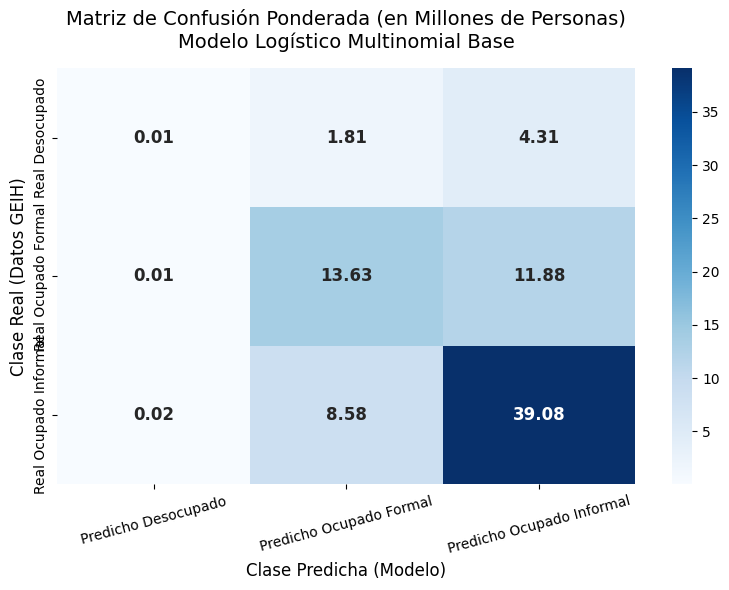

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ==============================================================================
# 1. CALCULAR LA MATRIZ DE CONFUSIÓN PONDERADA
# ==============================================================================
# Usamos w_test para mantener el rigor del factor de expansión del DANE
matriz_conf = confusion_matrix(y_test, y_pred, sample_weight=w_test)

# Convertimos los valores a millones de personas para facilitar la lectura en la gráfica
matriz_en_millones = matriz_conf / 1_000_000

# ==============================================================================
# 2. CREAR UN DATAFRAME PARA CONTROLAR LAS ETIQUETAS
# ==============================================================================
# Usamos el mismo orden alfabético estricto que detectó scikit-learn
nombres_ejes = ['Desocupado', 'Ocupado Formal', 'Ocupado Informal']

df_cm = pd.DataFrame(
    matriz_en_millones,
    index=[f'Real {c}' for c in nombres_ejes],
    columns=[f'Predicho {c}' for c in nombres_ejes]
)

# ==============================================================================
# 3. GRAFICAR LA MATRIZ COMO MAPA DE CALOR (HEATMAP)
# ==============================================================================
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_cm,
    annot=True,          # Muestra los números en los cuadros
    fmt=".2f",           # Dos decimales para los millones de personas
    cmap="Blues",        # Escala de azules
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Matriz de Confusión Ponderada (en Millones de Personas)\nModelo Logístico Multinomial Base", fontsize=14, pad=15)
plt.ylabel("Clase Real (Datos GEIH)", fontsize=12)
plt.xlabel("Clase Predicha (Modelo)", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Odds Ratio

In [ ]:
import numpy as np
import pandas as pd

# 1. Extraer la matriz de coeficientes global del modelo multinomial
coeficientes_globales = modelo_multinomial.coef_

# 2. Identificar los índices exactos de las clases en el modelo
idx_desocupado = clases_ordenadas.index('Desocupado')
idx_informal = clases_ordenadas.index('Ocupado Informal')

# ==============================================================================
# EXTRACCIÓN HISTORIA 1: EL DESEMPLEO (DESOCUPADOS)
# ==============================================================================
df_desempleo = pd.DataFrame({
    'Variable_Dummy': columnas_finales,
    'Coeficiente_Beta': coeficientes_globales[idx_desocupado]
})
df_desempleo['Odds_Ratio'] = np.exp(df_desempleo['Coeficiente_Beta'])
df_desempleo['Efecto_en_Desempleo'] = np.where(
    df_desempleo['Odds_Ratio'] > 1, 'Aumenta riesgo de Desempleo ↑', 'Protege / Disminuye Desempleo ↓'
)
df_desempleo = df_desempleo.sort_values(by='Odds_Ratio', ascending=False).reset_index(drop=True)

# ==============================================================================
# EXTRACCIÓN HISTORIA 2: LA INFORMALIDAD LABORAL
# ==============================================================================
df_informalidad = pd.DataFrame({
    'Variable_Dummy': columnas_finales,
    'Coeficiente_Beta': coeficientes_globales[idx_informal]
})
df_informalidad['Odds_Ratio'] = np.exp(df_informalidad['Coeficiente_Beta'])
df_informalidad['Efecto_en_Informalidad'] = np.where(
    df_informalidad['Odds_Ratio'] > 1, 'Aumenta riesgo de Informalidad ↑', 'Protege / Disminuye Informalidad ↓'
)
df_informalidad = df_informalidad.sort_values(by='Odds_Ratio', ascending=False).reset_index(drop=True)

# ==============================================================================
# REPORTES SIMULTÁNEOS PARA TU CAPÍTULO DE RESULTADOS
# ==============================================================================
print("============================================================")
print("     ANÁLISIS DE INTERPRETABILIDAD: DINÁMICA DEL DESEMPLEO")
print("============================================================")
print("\n🔥 Factores que más INCREMENTAN la probabilidad de estar Desocupado:")
display(df_desempleo[df_desempleo['Odds_Ratio'] > 1].head(5))

print("\n🛡️ Factores que más PROTEGEN contra el Desempleo:")
display(df_desempleo[df_desempleo['Odds_Ratio'] < 1].tail(5).iloc[::-1])

print("\n" + "="*60 + "\n")

print("============================================================")
print("     ANÁLISIS DE INTERPRETABILIDAD: DINÁMICA DE LA INFORMALIDAD")
print("============================================================")
print("\n🔥 Factores que más INCREMENTAN la probabilidad de ser Ocupado Informal:")
display(df_informalidad[df_informalidad['Odds_Ratio'] > 1].head(5))

print("\n🛡️ Factores que más PROTEGEN contra la Informalidad:")
display(df_informalidad[df_informalidad['Odds_Ratio'] < 1].tail(5).iloc[::-1])

     ANÁLISIS DE INTERPRETABILIDAD: DINÁMICA DEL DESEMPLEO

🔥 Factores que más INCREMENTAN la probabilidad de estar Desocupado:


,Variable_Dummy,Coeficiente_Beta,Odds_Ratio,Efecto_en_Desempleo
0,Etnia_3,0.721815,2.058164,Aumenta riesgo de Desempleo ↑
1,AREA_81,0.705987,2.025844,Aumenta riesgo de Desempleo ↑
2,AREA_86,0.662971,1.940549,Aumenta riesgo de Desempleo ↑
3,Etnia_4,0.565801,1.760857,Aumenta riesgo de Desempleo ↑
4,AREA_44,0.494280,1.639318,Aumenta riesgo de Desempleo ↑



🛡️ Factores que más PROTEGEN contra el Desempleo:


,Variable_Dummy,Coeficiente_Beta,Odds_Ratio,Efecto_en_Desempleo
71,Edad,-1.289319,0.275458,Protege / Disminuye Desempleo ↓
70,Estrato_6.0,-0.868838,0.419439,Protege / Disminuye Desempleo ↓
69,Escolaridad_13.0,-0.708477,0.492393,Protege / Disminuye Desempleo ↓
68,Estrato_5.0,-0.458118,0.632473,Protege / Disminuye Desempleo ↓
67,AREA_91,-0.407371,0.665398,Protege / Disminuye Desempleo ↓




     ANÁLISIS DE INTERPRETABILIDAD: DINÁMICA DE LA INFORMALIDAD

🔥 Factores que más INCREMENTAN la probabilidad de ser Ocupado Informal:


,Variable_Dummy,Coeficiente_Beta,Odds_Ratio,Efecto_en_Informalidad
0,Edad,1.106667,3.024263,Aumenta riesgo de Informalidad ↑
1,AREA_94,0.865326,2.375780,Aumenta riesgo de Informalidad ↑
2,AREA_97,0.590521,1.804929,Aumenta riesgo de Informalidad ↑
3,AREA_52,0.586851,1.798316,Aumenta riesgo de Informalidad ↑
4,AREA_91,0.515092,1.673792,Aumenta riesgo de Informalidad ↑



🛡️ Factores que más PROTEGEN contra la Informalidad:


,Variable_Dummy,Coeficiente_Beta,Odds_Ratio,Efecto_en_Informalidad
71,Escolaridad_13.0,-1.165883,0.311647,Protege / Disminuye Informalidad ↓
70,Escolaridad_12.0,-1.065545,0.344540,Protege / Disminuye Informalidad ↓
69,Escolaridad_7.0,-0.953814,0.385269,Protege / Disminuye Informalidad ↓
68,Escolaridad_11.0,-0.934963,0.392600,Protege / Disminuye Informalidad ↓
67,Escolaridad_10.0,-0.874958,0.416879,Protege / Disminuye Informalidad ↓


### Variables significativas según el Logit

In [ ]:
import numpy as np
import pandas as pd

# 1. Extraemos los coeficientes del modelo base
coeficientes_globales = modelo_multinomial.coef_
idx_desocupado = clases_ordenadas.index('Desocupado')
idx_informal = clases_ordenadas.index('Ocupado Informal')

# 2. Creamos un DataFrame consolidado para analizar la importancia estructural
df_significancia = pd.DataFrame({
    'Variable': columnas_finales,
    'Coef_Desempleo': coeficientes_globales[idx_desocupado],
    'Coef_Informalidad': coeficientes_globales[idx_informal]
})

# Calculamos la magnitud absoluta promedio para ver qué variables dominan el modelo en general
df_significancia['Impacto_Absoluto_Promedio'] = (
    df_significancia['Coef_Desempleo'].abs() + df_significancia['Coef_Informalidad'].abs()
) / 2

# Ordenamos por las variables más dominantes/significativas del sistema
df_significancia = df_significancia.sort_values(by='Impacto_Absoluto_Promedio', ascending=False).reset_index(drop=True)

# Umbral metodológico: filtramos variables con coeficientes casi nulos (ej. menores a 0.05)
# Esto limpia el ruido de variables que no aportan significancia al modelo
df_significativas = df_significancia[df_significancia['Impacto_Absoluto_Promedio'] >= 0.05].copy()

# ==============================================================================
# REPORTES DE SIGNIFICANCIA PARA EL DOCUMENTO
# ==============================================================================
print("============================================================")
print(f"   VARIABLES SIGNIFICATIVAS DETECTADAS: {df_significativas.shape[0]} de {df_significancia.shape[1]}")
print("============================================================")
print("\nTop 15 variables con mayor peso e impacto estructural en el mercado laboral:")
display(df_significativas.head(15))

print("\n📉 Variables no significativas o con impacto nulo (Ruido eliminado):")
display(df_significancia[df_significancia['Impacto_Absoluto_Promedio'] < 0.05])

   VARIABLES SIGNIFICATIVAS DETECTADAS: 68 de 4

Top 15 variables con mayor peso e impacto estructural en el mercado laboral:


,Variable,Coef_Desempleo,Coef_Informalidad,Impacto_Absoluto_Promedio
0,Edad,-1.289319,1.106667,1.197993
1,Escolaridad_13.0,-0.708477,-1.165883,0.937180
2,Escolaridad_12.0,-0.271176,-1.065545,0.668360
3,Escolaridad_7.0,0.246173,-0.953814,0.599994
4,Estrato_6.0,-0.868838,0.308142,0.588490
5,Escolaridad_11.0,-0.241025,-0.934963,0.587994
6,Etnia_3,0.721815,-0.395329,0.558572
7,Etnia_4,0.565801,-0.513836,0.539818
8,AREA_94,-0.098946,0.865326,0.482136
9,AREA_86,0.662971,0.282570,0.472771



📉 Variables no significativas o con impacto nulo (Ruido eliminado):


,Variable,Coef_Desempleo,Coef_Informalidad,Impacto_Absoluto_Promedio
68,AREA_66,-0.054694,0.029709,0.042202
69,AREA_17,0.040400,0.025876,0.033138
70,Estado_Civil_2.0,-0.040560,0.016344,0.028452
71,Escolaridad_99.0,-0.008581,0.015232,0.011907


## Random Forest

### Primer modelo

*Genera la Tabla 6 de la sección 4.5.2.1*

In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score

# ============================================================
# 1. INSTANCIAR EL MODELO BASE DE RANDOM FOREST
# ============================================================
# Se asume que X_train y X_test ya están transformados (Numéricos y One-Hot)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# ============================================================
# 2. DEFINICIÓN DE LA MALLA DE HIPERPARÁMETROS (GRID)
# ============================================================
# Nota: Como ya no hay Pipeline, los nombres de los parámetros van directos
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# ============================================================
# 3. CONFIGURACIÓN Y EJECUCIÓN DE GRIDSEARCHCV CON FEX
# ============================================================
# StratifiedKFold asegura mantener las proporciones de las 3 clases en cada fold
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc_ovr_weighted',  # Métrica multinomial requerida
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)

print("Iniciando GridSearchCV para Random Forest...")
print("Optimizando bajo la métrica: roc_auc_ovr_weighted (Usando FEX)\n")

# Se pasa el Factor de Expansión de entrenamiento (w_train) mediante sample_weight
grid_search.fit(
    X_train,
    y_train,
    sample_weight=w_train
)

# ============================================================
# 4. REPORTAR LOS MEJORES RESULTADOS DE LA BÚSQUEDA
# ============================================================
print("\n============================================================")
print("             RESULTADOS DE LA OPTIMIZACIÓN")
print("============================================================")
print(f"Mejor puntuación (ROC-AUC ponderado en CV): {grid_search.best_score_:.4f}")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  -> {param}: {value}")
print("------------------------------------------------------------")

# Extraemos el mejor modelo entrenado
best_rf_model = grid_search.best_estimator_

# ============================================================
# 5. EVALUACIÓN FINAL EN EL CONJUNTO DE TEST (OCT-DIC)
# ============================================================
# Predicciones con el modelo optimizado
y_pred_opt = best_rf_model.predict(X_test)
y_prob_opt = best_rf_model.predict_proba(X_test)

# Reporte de clasificación final ponderado por la población real (w_test)
print("\n============================================================")
print("     REPORTE DE CLASIFICACIÓN FINAL PONDERADO (TEST: OCT-DIC)")
print("============================================================")
print(classification_report(y_test, y_pred_opt, sample_weight=w_test))

# Calcular el ROC-AUC score ponderado final en Test (One-vs-Rest)
roc_auc_test = roc_auc_score(
    y_test, y_prob_opt,
    multi_class='ovr',
    average='weighted',
    sample_weight=w_test
)
print(f"ROC-AUC Final en Test (Ponderado por FEX): {roc_auc_test:.4f}")
print("============================================================")

Iniciando GridSearchCV para Random Forest...
Optimizando bajo la métrica: roc_auc_ovr_weighted (Usando FEX)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



             RESULTADOS DE LA OPTIMIZACIÓN
Mejor puntuación (ROC-AUC ponderado en CV): 0.7426
Mejores hiperparámetros encontrados:
  -> max_depth: 15
  -> max_features: sqrt
  -> min_samples_split: 10
  -> n_estimators: 300
------------------------------------------------------------

     REPORTE DE CLASIFICACIÓN FINAL PONDERADO (TEST: OCT-DIC)
                  precision    recall  f1-score   support

      Desocupado       0.29      0.01      0.02 6136304.266130701
  Ocupado Formal       0.58      0.57      0.58 25509697.886938255
Ocupado Informal       0.72      0.82      0.77 47682210.3238056

        accuracy                           0.68 79328212.47687456
       macro avg       0.53      0.47      0.45 79328212.47687456
    weighted avg       0.64      0.68      0.65 79328212.47687456

ROC-AUC Final en Test (Ponderado por FEX): 0.7686


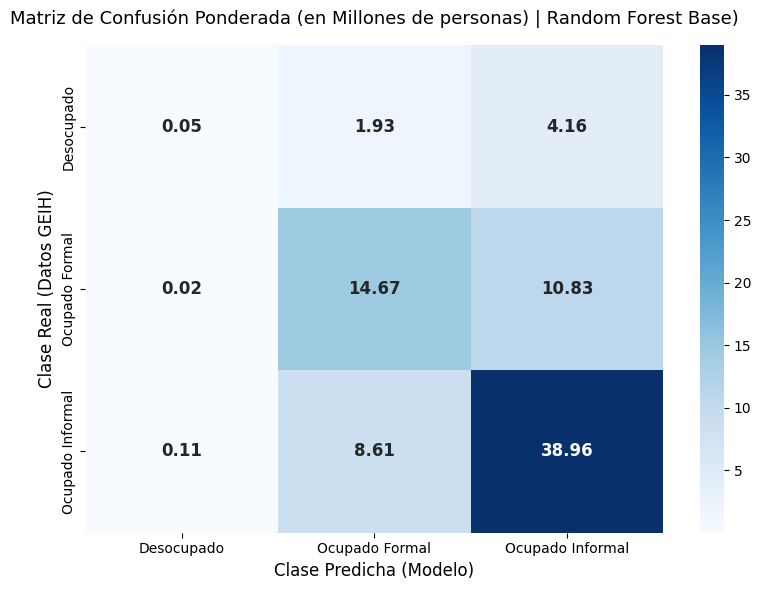

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Calcular la matriz de confusión ponderada por el FEX (w_test)
# Usamos 'y_pred_opt', que son las predicciones del primer modelo sin balancear
cm_poblacional_base = confusion_matrix(y_test, y_pred_opt, sample_weight=w_test)

# 2. Convertir los valores absolutos a millones de personas
cm_en_millones_base = cm_poblacional_base / 1_000_000

# 3. Crear las etiquetas de texto personalizadas para cada celda (Ej: "12.54M")
labels_base = [["{:.2f}".format(valor) for valor in fila] for fila in cm_en_millones_base]

# Nombres exactos de tus clases en el orden numérico del modelo
nombres_clases = ['Desocupado', 'Ocupado Formal', 'Ocupado Informal']

# 4. Graficar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_en_millones_base,
    annot=labels_base,     # Inyecta las etiquetas formateadas en millones
    fmt="",                # Evita que seaborn sobreescriba el formato de texto
    cmap="Blues",          # Escala de colores en tonos azules
    cbar=True,
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
    annot_kws={"size": 12, "weight": "bold"} # Resalta las cifras internas
)

# Ajustes de títulos y etiquetas para los anexos o cuerpo de tu TFM
plt.title('Matriz de Confusión Ponderada (en Millones de personas) | Random Forest Base)', fontsize=13, pad=15)
plt.ylabel('Clase Real (Datos GEIH)', fontsize=12)
plt.xlabel('Clase Predicha (Modelo)', fontsize=12)
plt.tight_layout()

# Guardar la imagen para el documento final de tesis
# plt.savefig('matriz_confusion_rf_baseline_millones.png', dpi=300)

plt.show()

### Segundo modelo

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# ============================================================
# 1. INSTANCIAR EL MODELO BASE DE RANDOM FOREST
# ============================================================
# Se asume que X_train y X_test ya están transformados (Numéricos y One-Hot)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Calcular el peso teórico inverso de cada clase para mitigar el desbalance
# Esto le dará más importancia a la clase 'Desocupado'
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
# ============================================================
# 2. DEFINICIÓN DE LA MALLA DE HIPERPARÁMETROS (GRID)
# ============================================================
# Nota: Como ya no hay Pipeline, los nombres de los parámetros van directos
param_grid = {
    'n_estimators': [300],
    'max_depth': [15],
    'min_samples_split': [5, 10,15],
    'max_features': ['sqrt', 'log2']
}

# ============================================================
# 3. CONFIGURACIÓN Y EJECUCIÓN DE GRIDSEARCHCV CON FEX
# ============================================================
# StratifiedKFold asegura mantener las proporciones de las 3 clases en cada fold
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc_ovr_weighted',  # Métrica multinomial requerida
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    error_score='raise'
)
# Crear un diccionario para mapear la clase con su respectivo peso de penalización
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Pesos de penalización por clase:", class_weight_dict)

# 2. Multiplicar el FEX original por el peso de su respectiva clase
# w_train_balanced será el nuevo vector de pesos para el .fit()
mapping_weights = np.vectorize(class_weight_dict.get)(y_train)
w_train_balanced = w_train * mapping_weights

# 3. Volver a correr tu GridSearchCV usando este nuevo vector de pesos
print("\nIniciando GridSearchCV con Pesos Ponderados y Balanceados...")
grid_search.fit(
    X_train,
    y_train,
    sample_weight=w_train_balanced # <--- Aquí pasamos la corrección
)

# Extraer el nuevo mejor modelo y evaluar
best_rf_model_v2 = grid_search.best_estimator_

Pesos de penalización por clase: {'Desocupado': np.float64(3.1076121219687276), 'Ocupado Formal': np.float64(1.0963071434863032), 'Ocupado Informal': np.float64(0.5662333378827169)}

Iniciando GridSearchCV con Pesos Ponderados y Balanceados...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


*Genera la Tabla 8 y la Figura 18 de la sección 4.5.2.2*


   REPORTE DE CLASIFICACIÓN FINAL PONDERADO (MODELO BALANCEADO)
                  precision    recall  f1-score   support

      Desocupado       0.19      0.33      0.24 6136304.266130701
  Ocupado Formal       0.53      0.74      0.62 25509697.886938255
Ocupado Informal       0.82      0.56      0.67 47682210.3238056

        accuracy                           0.60 79328212.47687456
       macro avg       0.51      0.55      0.51 79328212.47687456
    weighted avg       0.68      0.60      0.62 79328212.47687456

ROC-AUC Final Corregido en Test (Ponderado por FEX): 0.7626


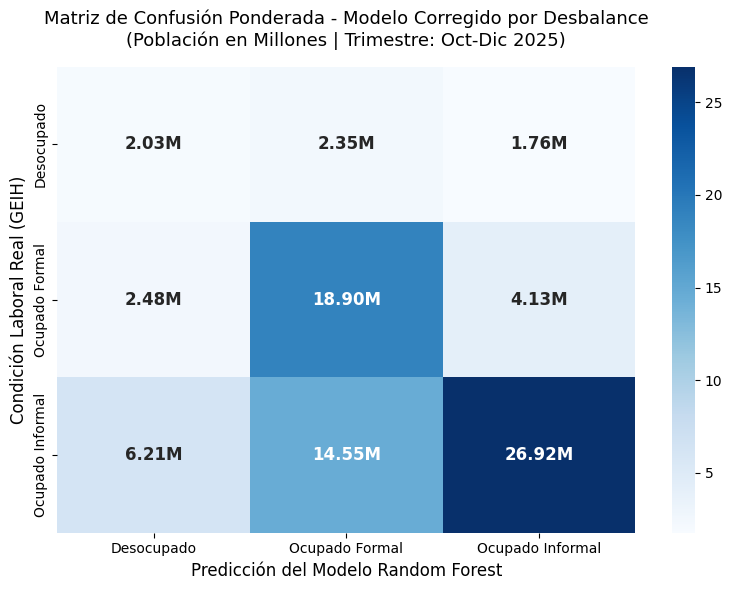

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. GENERAR PREDICCIONES CON EL MODELO CORREGIDO
# ============================================================
y_pred_bal = best_rf_model_v2.predict(X_test)
y_prob_bal = best_rf_model_v2.predict_proba(X_test)

# Nombres exactos de tus clases mapeadas en el orden numérico del modelo
nombres_clases = ['Desocupado', 'Ocupado Formal', 'Ocupado Informal']

# ============================================================
# 2. REPORTE DE CLASIFICACIÓN FINAL PONDERADO (FEX)
# ============================================================
print("\n============================================================")
print("   REPORTE DE CLASIFICACIÓN FINAL PONDERADO (MODELO BALANCEADO)")
print("============================================================")
# Evaluamos usando w_test para proyectar los resultados correctamente a la población colombiana
print(classification_report(y_test, y_pred_bal, target_names=nombres_clases, sample_weight=w_test))

# Calcular el nuevo ROC-AUC score ponderado final en Test (One-vs-Rest)
roc_auc_test_bal = roc_auc_score(
    y_test, y_prob_bal,
    multi_class='ovr',
    average='weighted',
    sample_weight=w_test
)
print(f"ROC-AUC Final Corregido en Test (Ponderado por FEX): {roc_auc_test_bal:.4f}")
print("============================================================")


# ============================================================
# 3. GENERAR MATRIZ DE CONFUSIÓN EN MILLONES DE PERSONAS
# ============================================================
# Calcular la matriz sumando las ponderaciones poblacionales de w_test
cm_poblacional_bal = confusion_matrix(y_test, y_pred_bal, sample_weight=w_test)

# Convertir las celdas absolutas a millones de personas
cm_en_millones_bal = cm_poblacional_bal / 1_000_000

# Formatear las etiquetas de texto internas para cada celda (Ej: "4.25M")
labels_bal = [["{:.2f}M".format(valor) for valor in fila] for fila in cm_en_millones_bal]

# Configurar y pintar el mapa de calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_en_millones_bal,
    annot=labels_bal,       # Inyectar textos formateados en millones
    fmt="",                 # Evitar que seaborn altere el string
    cmap="Blues",           # Escala de tonos azules
    cbar=True,
    xticklabels=nombres_clases,
    yticklabels=nombres_clases,
    annot_kws={"size": 12, "weight": "bold"} # Estilo para resaltar los datos
)

# Títulos del gráfico orientados a la redacción del TFM
plt.title('Matriz de Confusión Ponderada - Modelo Corregido por Desbalance\n(Población en Millones | Trimestre: Oct-Dic 2025)', fontsize=13, pad=15)
plt.ylabel('Condición Laboral Real (GEIH)', fontsize=12)
plt.xlabel('Predicción del Modelo Random Forest', fontsize=12)
plt.tight_layout()

# Descomenta la línea de abajo si quieres guardar el gráfico directamente en tu carpeta de trabajo
# plt.savefig('matriz_confusion_rf_balanceado_millones.png', dpi=300)

plt.show()

## XG Boost

### XG Boost Estándar

*Genera la Tabla 9 de la sección 4.5.3.1*

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("Preparando y entrenando el modelo XGBoost con las matrices finales del TFM...")

# ==============================================================================
# 1. BLINDAJE DE NOMBRES DE COLUMNAS (Para evitar errores de sintaxis en XGBoost)
# ==============================================================================
X_train_xgb = X_train_final.copy()
X_test_xgb = X_test_final.copy()

# Reemplazamos caracteres especiales que el codificador de XGBoost rechaza
X_train_xgb.columns = X_train_xgb.columns.str.replace(r'[\[\]<>\s]', '_', regex=True)
X_test_xgb.columns = X_test_xgb.columns.str.replace(r'[\[\]<>\s]', '_', regex=True)

# ==============================================================================
# 2. CODIFICACIÓN EXPLICITA DEL TARGET (Requisito de XGBoost para multiclase)
# ==============================================================================
# XGBoost necesita que las clases sean 0, 1 y 2 en lugar de texto
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# ==============================================================================
# 3. CONFIGURACIÓN Y ENTRENAMIENTO DEL MODELO GRADIENT BOOSTING
# ==============================================================================
modelo_xgb = XGBClassifier(
    n_estimators=100,         # Número de árboles secuenciales
    max_depth=6,              # Profundidad para controlar el sobreajuste
    learning_rate=0.1,        # Ritmo de aprendizaje
    random_state=42,          # Tu semilla para replicabilidad exacta
    tree_method='hist',       # Optimización para acelerar el cálculo con la GEIH
    n_jobs=-1                 # Usa todos los procesadores
)

# Ajustamos el modelo usando el factor de expansión real (w_train)
modelo_xgb.fit(X_train_xgb, y_train_encoded, sample_weight=w_train)

# Predicciones sobre el set de prueba temporal
y_pred_xgb_encoded = modelo_xgb.predict(X_test_xgb)

# Devolvemos las predicciones a sus nombres de texto originales ('Desocupado', etc.)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

# ==============================================================================
# 4. EVALUACIÓN DEL RENDIMIENTO PONDERADO
# ==============================================================================
accuracy_test_xgb = modelo_xgb.score(X_test_xgb, y_test_encoded, sample_weight=w_test)

print("="*60)
print(f"   EXACTITUD GLOBAL PONDERADA XGB (ACCURACY): {accuracy_test_xgb * 100:.2f}%")
print("="*60 + "\n")

print("=== REPORTE DE CLASIFICACIÓN DETALLADO (XGBOOST) ===")
print(classification_report(y_test, y_pred_xgb, sample_weight=w_test))

Preparando y entrenando el modelo XGBoost con las matrices finales del TFM...
   EXACTITUD GLOBAL PONDERADA XGB (ACCURACY): 67.33%

=== REPORTE DE CLASIFICACIÓN DETALLADO (XGBOOST) ===
                  precision    recall  f1-score   support

      Desocupado       0.30      0.01      0.01 6136304.266130701
  Ocupado Formal       0.58      0.56      0.57 25509697.886938255
Ocupado Informal       0.72      0.82      0.76 47682210.3238056

        accuracy                           0.67 79328212.47687456
       macro avg       0.53      0.46      0.45 79328212.47687456
    weighted avg       0.64      0.67      0.64 79328212.47687456



### XG BOOST - (FEX + Castigo)

*Genera la Tabla 10 de la sección 4.5.3.2*

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

print("Calculando la matriz de castigo por desbalance estructural...")

# ==============================================================================
# 1. CÁLCULO DEL MULTIPLICADOR DE ATENCIÓN (Pesos Inversamente Proporcionales)
# ==============================================================================
pesos_clases = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)

dicc_pesos = dict(zip(np.unique(y_train_encoded), pesos_clases))

# MULTIPLICACIÓN MATEMÁTICA: FEX original * Castigo de su Clase
w_train_balanceado = w_train * np.array([dicc_pesos[clase] for clase in y_train_encoded])

print(f"Pesos de penalización analítica aplicados:")
for idx, clase_orig in enumerate(le.classes_):
    print(f" - Clientes en {clase_orig}: Multiplicador de FEX x{pesos_clases[idx]:.2f}")

# ==============================================================================
# 2. ENTRENAMIENTO DEL MODELO XGBOOST OPTIMIZADO
# ==============================================================================
print("\nEntrenando XGBoost con FEX + Penalización por Desbalance...")

modelo_xgb_bal = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

modelo_xgb_bal.fit(X_train_xgb, y_train_encoded, sample_weight=w_train_balanceado)

# Predicciones
y_pred_xgb_bal_enc = modelo_xgb_bal.predict(X_test_xgb)
y_pred_xgb_bal = le.inverse_transform(y_pred_xgb_bal_enc)

# ==============================================================================
# 3. EVALUACIÓN DEL RENDIMIENTO PONDERADO REAL
# ==============================================================================
accuracy_test_xgb_bal = modelo_xgb_bal.score(X_test_xgb, y_test_encoded, sample_weight=w_test)

print("\n" + "="*60)
print(f"   EXACTITUD GLOBAL REAL (ACCURACY): {accuracy_test_xgb_bal * 100:.2f}%")
print("="*60 + "\n")

print("=== REPORTE DETALLADO: XGBOOST CON REBALANCEO ANALÍTICO ===")
print(classification_report(y_test, y_pred_xgb_bal, sample_weight=w_test))

Calculando la matriz de castigo por desbalance estructural...
Pesos de penalización analítica aplicados:
 - Clientes en Desocupado: Multiplicador de FEX x3.11
 - Clientes en Ocupado Formal: Multiplicador de FEX x1.10
 - Clientes en Ocupado Informal: Multiplicador de FEX x0.57

Entrenando XGBoost con FEX + Penalización por Desbalance...

   EXACTITUD GLOBAL REAL (ACCURACY): 58.20%

=== REPORTE DETALLADO: XGBOOST CON REBALANCEO ANALÍTICO ===
                  precision    recall  f1-score   support

      Desocupado       0.18      0.40      0.25 6136304.266130701
  Ocupado Formal       0.52      0.73      0.61 25509697.886938255
Ocupado Informal       0.83      0.53      0.64 47682210.3238056

        accuracy                           0.58 79328212.47687456
       macro avg       0.51      0.55      0.50 79328212.47687456
    weighted avg       0.68      0.58      0.60 79328212.47687456



### XG Boost con optimización de hiperparámetros - SELECCIONADO


*Genera la Tabla 11 de la sección 4.5.3.3*

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np

print("Iniciando la optimización de hiperparámetros mediante GridSearchCV...")
print("Nota: Este proceso puede tardar unos minutos debido al volumen de la GEIH.\n")

# 1. Definimos el modelo base con el vector de pesos balanceado que ya calculamos
xgb_base = XGBClassifier(
    n_estimators=150,        # Aumentamos los árboles para compensar el paso más lento
    learning_rate=0.05,      # Aprendizaje más suave y preciso
    tree_method='hist',      # Optimización matemática para bases de datos grandes
    random_state=42,
    n_jobs=-1
)

# 2. Definimos la cuadrícula de parámetros a testear
param_grid = {
    'max_depth': [6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 3. Configuramos la búsqueda enfocando la optimización en el ROC-AUC Ponderado
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc_ovr_weighted', # Forzamos a buscar el mejor ROC-AUC OvR Ponderado
    cv=3,                           # 3 pliegues para validación cruzada (balance balance/tiempo)
    verbose=2,
    n_jobs=-1
)

# 4. Ajustamos la búsqueda usando nuestro vector w_train_balanceado (FEX + Castigo)
grid_search.fit(X_train_xgb, y_train_encoded, sample_weight=w_train_balanceado)

# 5. Extraemos el mejor modelo encontrado
modelo_xgb_final = grid_search.best_estimator_

print("\n" + "="*60)
print("¡Optimización Completada con Éxito!")
print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")
print("="*60 + "\n")

# ==============================================================================
# EVALUACIÓN DEL MODELO FINAL DE LA TESIS
# ==============================================================================
# Probabilidades y predicciones
y_prob_final = modelo_xgb_final.predict_proba(X_test_xgb)
y_pred_final_enc = modelo_xgb_final.predict(X_test_xgb)
y_pred_final = le.inverse_transform(y_pred_final_enc)

# Cálculo de Métricas Finales contra el w_test puro del DANE
roc_final = roc_auc_score(y_test_encoded, y_prob_final, multi_class='ovr', average='weighted', sample_weight=w_test)
rep_final = classification_report(y_test, y_pred_final, sample_weight=w_test, output_dict=True)

print(f"▶ NUEVO ROC-AUC PONDERADO (OvR): {roc_final:.4f}")
print(f"▶ NUEVA EXACTITUD GLOBAL (ACCURACY): {rep_final['accuracy'] * 100:.2f}%")
print(f"▶ NUEVO MACRO F1-SCORE: {rep_final['macro avg']['f1-score']:.4f}\n")

print("=== REPORTE DETALLADO: XGBOOST FINAL CALIBRADO ===")
print(classification_report(y_test, y_pred_final, sample_weight=w_test))

Iniciando la optimización de hiperparámetros mediante GridSearchCV...
Nota: Este proceso puede tardar unos minutos debido al volumen de la GEIH.

Fitting 3 folds for each of 8 candidates, totalling 24 fits

¡Optimización Completada con Éxito!
Mejores hiperparámetros encontrados: {'colsample_bytree': 0.8, 'max_depth': 8, 'subsample': 0.8}

▶ NUEVO ROC-AUC PONDERADO (OvR): 0.7629
▶ NUEVA EXACTITUD GLOBAL (ACCURACY): 58.58%
▶ NUEVO MACRO F1-SCORE: 0.5035

=== REPORTE DETALLADO: XGBOOST FINAL CALIBRADO ===
                  precision    recall  f1-score   support

      Desocupado       0.18      0.39      0.25 6136304.266130701
  Ocupado Formal       0.52      0.74      0.61 25509697.886938255
Ocupado Informal       0.83      0.53      0.65 47682210.3238056

        accuracy                           0.59 79328212.47687456
       macro avg       0.51      0.55      0.50 79328212.47687456
    weighted avg       0.68      0.59      0.61 79328212.47687456



#### Matriz de Confusión

*Genera la Figura 19 de la sección 4.5.3.3*

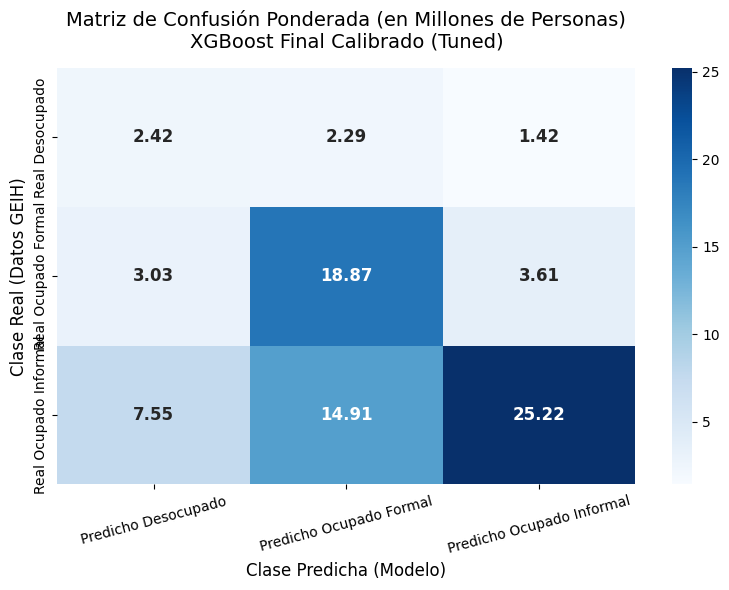

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# ==============================================================================
# 1. CALCULAR LA MATRIZ DE CONFUSIÓN PONDERADA (XGBOOST TUNED)
# ==============================================================================
matriz_conf_xgb = confusion_matrix(y_test, y_pred_final, sample_weight=w_test)

# Convertimos los valores a millones de personas para mantener la escala macro de la GEIH
matriz_en_millones_xgb = matriz_conf_xgb / 1_000_000

# ==============================================================================
# 2. CREAR UN DATAFRAME PARA CONTROLAR LAS ETIQUETAS
# ==============================================================================
nombres_ejes = ['Desocupado', 'Ocupado Formal', 'Ocupado Informal']

df_cm_xgb = pd.DataFrame(
    matriz_en_millones_xgb,
    index=[f'Real {c}' for c in nombres_ejes],
    columns=[f'Predicho {c}' for c in nombres_ejes]
)

# ==============================================================================
# 3. GRAFICAR LA MATRIZ COMO MAPA DE CALOR (HEATMAP)
# ==============================================================================
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_cm_xgb,
    annot=True,          # Muestra los millones de personas en los cuadros
    fmt=".2f",           # Dos decimales para el rigor econométrico
    cmap="Blues",        # ESCALA DE AZULES para mantener coherencia gráfica
    cbar=True,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title("Matriz de Confusión Ponderada (en Millones de Personas)\nXGBoost Final Calibrado (Tuned)", fontsize=14, pad=15)
plt.ylabel("Clase Real (Datos GEIH)", fontsize=12)
plt.xlabel("Clase Predicha (Modelo)", fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Gain Feature Importance

In [ ]:
import numpy as np
import pandas as pd

# ==============================================================================
# 1. EXTRACCIÓN DE LA IMPORTANCIA NATIVA DE VARIABLES (XGBOOST TUNED)
# ==============================================================================
# Extraemos el vector de ganancia global del modelo multiclase
importancias_globales = modelo_xgb_final.feature_importances_

# Creamos el DataFrame unificado de Relevancia Estructural
df_ganancia_global = pd.DataFrame({
    'Variable_Dummy': columnas_finales,
    'Importancia_Ganancia': importancias_globales
})

# Ordenamos de mayor a menor según su capacidad de reducción de impureza
df_ganancia_global = df_ganancia_global.sort_values(by='Importancia_Ganancia', ascending=False).reset_index(drop=True)

# ==============================================================================
# REPORTES PARA EL CAPÍTULO DE RESULTADOS (GANANCIA GLOBAL)
# ==============================================================================
print("=====================================================================")
print("  ANÁLISIS DE RELEVANCIA ESTRUCTURAL: GANANCIA GLOBAL DE XGBOOST")
print("=====================================================================")
print("\nJerarquía de variables según su poder de partición en los nodos:")

# Desplegamos el top completo de variables que estructuran tus árboles
display(df_ganancia_global.head(15))

  ANÁLISIS DE RELEVANCIA ESTRUCTURAL: GANANCIA GLOBAL DE XGBOOST

Jerarquía de variables según su poder de partición en los nodos:


,Variable_Dummy,Importancia_Ganancia
0,Escolaridad_3.0,0.131900
1,Sabe_leer_Escribir_2.0,0.060097
2,Escolaridad_4.0,0.057433
3,Zona_2,0.040250
4,Estrato_1.0,0.036782
5,Escolaridad_5.0,0.030077
6,AREA_44,0.021172
7,Escolaridad_12.0,0.019670
8,Escolaridad_11.0,0.019343
9,AREA_25,0.019093


#### Variables significativas

In [ ]:
import numpy as np
import pandas as pd

print("Calculando el impacto estructural y variables significativas del XGBoost Final...")

# ==============================================================================
# 1. EXTRACCIÓN DE LA IMPORTANCIA ESTRUCTURAL GLOBAL
# ==============================================================================
importancias_globales = modelo_xgb_final.feature_importances_

# Creamos el DataFrame consolidado usando la métrica de Ganancia del árbol
df_significancia_xgb = pd.DataFrame({
    'Variable': columnas_finales,
    'Impacto_Estructural_Gain': importancias_globales
})

# Ordenamos por las variables más dominantes del sistema completo
df_significancia_xgb = df_significancia_xgb.sort_values(by='Impacto_Estructural_Gain', ascending=False).reset_index(drop=True)

# ==============================================================================
# 2. CONFIGURACIÓN DEL UMBRAL METODOLÓGICO (FILTRO DE RUIDO)
# ==============================================================================
# Establecemos que una variable es significativa si aporta al menos el 0.5% (0.005) de la ganancia total
umbral_ganancia = 0.005
df_significativas_xgb = df_significancia_xgb[df_significancia_xgb['Impacto_Estructural_Gain'] >= umbral_ganancia].copy()

# ==============================================================================
# REPORTES DE SIGNIFICANCIA PARA EL DOCUMENTO
# ==============================================================================
print("=====================================================================")
print(f"   VARIABLES SIGNIFICATIVAS DETECTADAS: {df_significativas_xgb.shape[0]} de {df_significancia_xgb.shape[0]}")
print("=====================================================================")
print("\nTop 15 variables con mayor peso e impacto estructural en el mercado laboral colombiano (XGBoost):")
display(df_significativas_xgb.head(15))

print(f"\n📉 Variables no significativas o con impacto nulo (Ruido eliminado con umbral < {umbral_ganancia}):")
display(df_significancia_xgb[df_significancia_xgb['Impacto_Estructural_Gain'] < umbral_ganancia])

Calculando el impacto estructural y variables significativas del XGBoost Final...
   VARIABLES SIGNIFICATIVAS DETECTADAS: 61 de 72

Top 15 variables con mayor peso e impacto estructural en el mercado laboral colombiano (XGBoost):


,Variable,Impacto_Estructural_Gain
0,Escolaridad_3.0,0.110879
1,Escolaridad_4.0,0.056412
2,Sabe_leer_Escribir_2.0,0.055802
3,Zona_2,0.039527
4,Estrato_1.0,0.039486
5,Escolaridad_5.0,0.031349
6,Escolaridad_11.0,0.022299
7,AREA_44,0.021277
8,Escolaridad_12.0,0.021212
9,AREA_25,0.019358



📉 Variables no significativas o con impacto nulo (Ruido eliminado con umbral < 0.005):


,Variable,Impacto_Estructural_Gain
61,Etnia_2,0.004295
62,Escolaridad_2.0,0.003692
63,AREA_85,0.003345
64,AREA_17,0.003211
65,AREA_88,0.003090
66,AREA_63,0.003049
67,AREA_66,0.002981
68,AREA_95,0.001665
69,AREA_99,0.000764
70,AREA_97,0.000181


#### SHAP Informalidad

*Genera la Figura 21 de la sección 6.1*

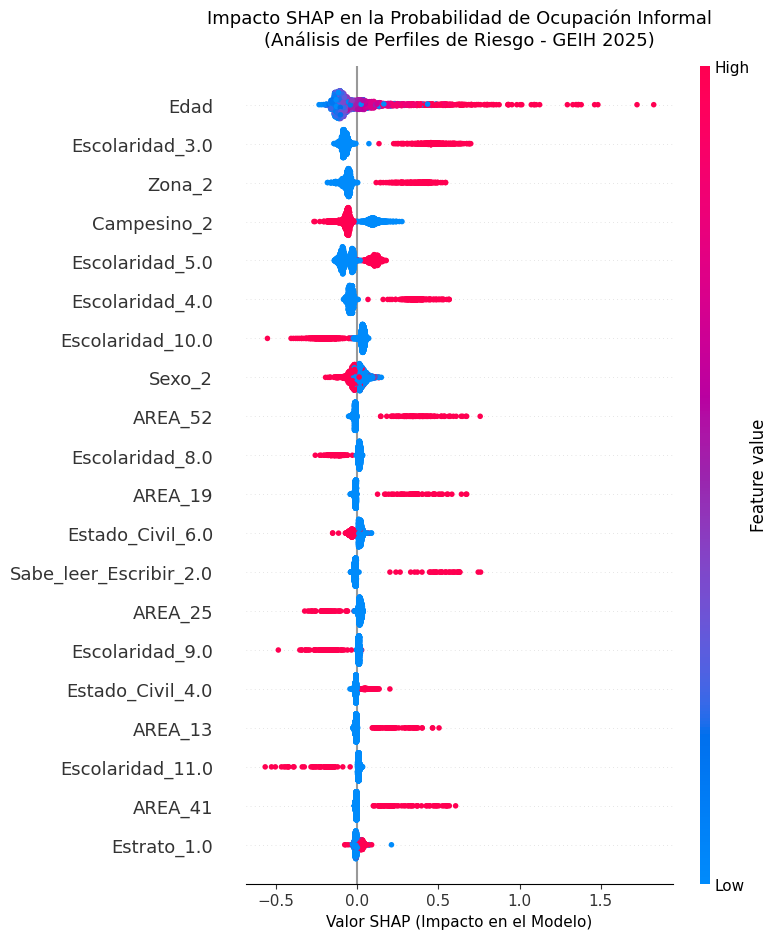

In [ ]:
import shap
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CREAR EL EXPLICADOR SHAP (TreeExplainer Nativo para XGBoost)
# ==============================================================================
explainer = shap.TreeExplainer(modelo_xgb_final)

# ==============================================================================
# 2. SELECCIÓN DE LA MUESTRA ESTRATÉGICA (Evita colapsos de memoria)
# ==============================================================================
# 2,000 registros es un tamaño excelente para representar las tendencias de la GEIH
X_test_sample = X_test_xgb.sample(2000, random_state=42)

# Calcular los valores SHAP (puede tardar un par de minutos según tu procesador)
shap_values = explainer(X_test_sample)

# ==============================================================================
# 3. CONFIGURACIÓN Y DESPLIEGUE DEL SUMMARY PLOT (Ocupado Informal)
# ==============================================================================
plt.figure(figsize=(10, 6))

# CORRECCIÓN DE INDEXACIÓN MULTICLASE:
# Accedemos a la tercera dimensión (.values[..., 2]) que mapea al Ocupado Informal
shap.summary_plot(
    shap_values.values[..., 2],
    X_test_sample,
    plot_type="dot",
    show=False
)

# Estilización académica para los títulos de la tesis
plt.title('Impacto SHAP en la Probabilidad de Ocupación Informal\n(Análisis de Perfiles de Riesgo - GEIH 2025)', fontsize=13, pad=15)
plt.xlabel('Valor SHAP (Impacto en el Modelo)', fontsize=11)
plt.tight_layout()

# Descomenta para guardar la figura directamente en alta resolución para tu Word/LaTeX
# plt.savefig('shap_summary_informalidad.png', dpi=300)
plt.show()

#### SHAP Desempleo

*Genera la Figura 20 de la sección 6.1*

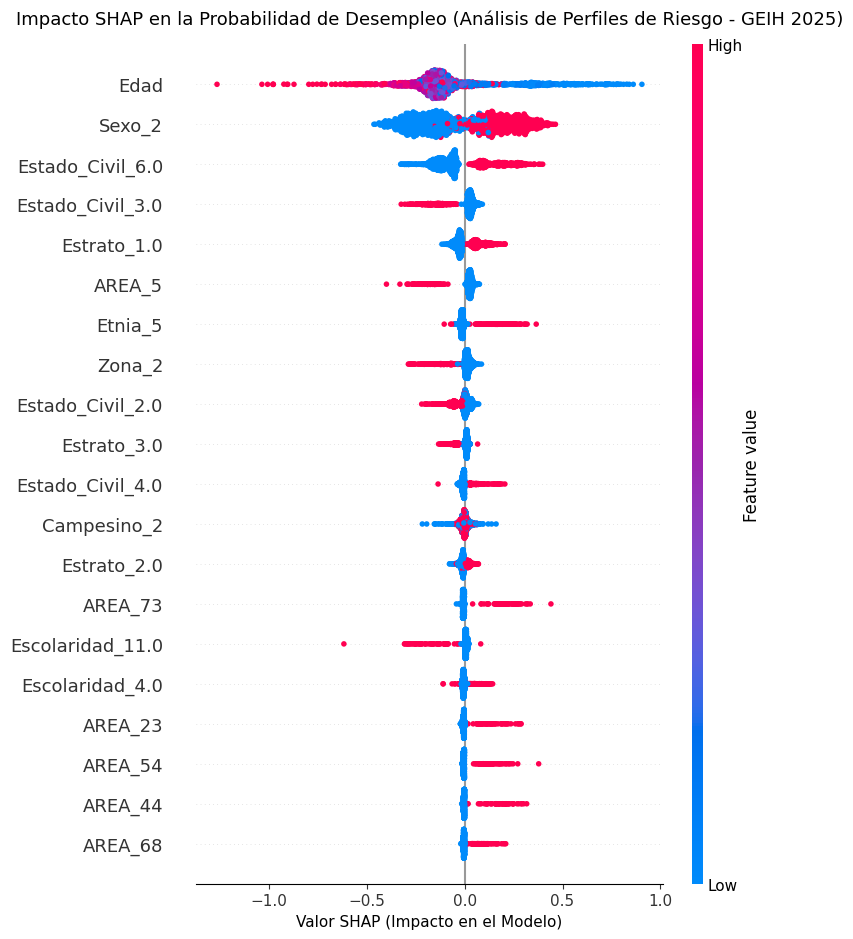

In [ ]:
# Corre esta línea para tu capítulo de desempleo:
shap.summary_plot(
    shap_values.values[..., 0], # <--- Cambiado a 0 para analizar al Desocupado
    X_test_sample,
    plot_type="dot",
    show=False
)

# Estilización académica para los títulos de la tesis
plt.title('Impacto SHAP en la Probabilidad de Desempleo (Análisis de Perfiles de Riesgo - GEIH 2025)', fontsize=13, pad=15)
plt.xlabel('Valor SHAP (Impacto en el Modelo)', fontsize=11)
plt.tight_layout()

# Descomenta para guardar la figura directamente en alta resolución para tu Word/LaTeX
# plt.savefig('shap_summary_informalidad.png', dpi=300)
plt.show()

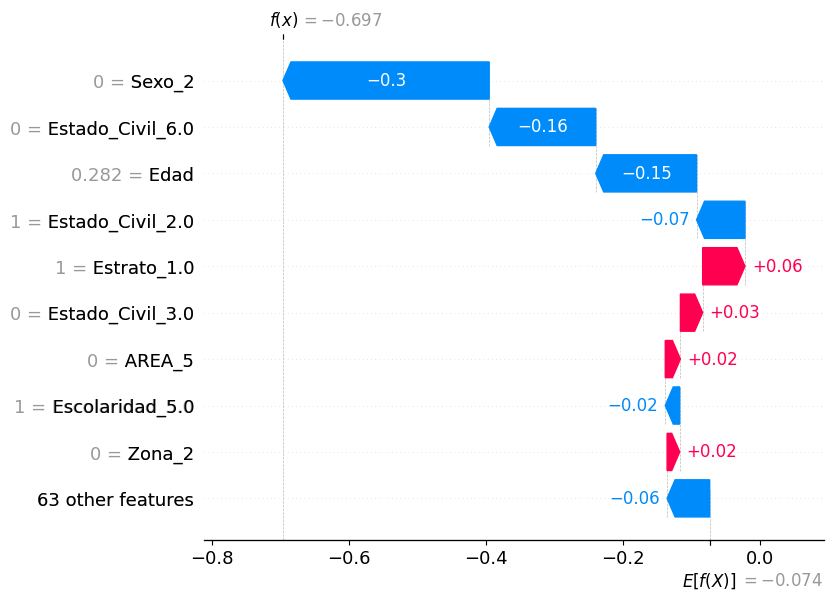

In [ ]:
# Código para ver un perfil específico (ejemplo: la fila 42 de tu muestra)
# Si esa fila es una mujer, joven, de Ibagué y Estrato 1, verás su descomposición exacta.
shap.plots.waterfall(shap_values[42, :, 0]) # El 0 es para desempleo

# **Comparativa de los modelos**

## Comparación Global

*Genera la Tabla 12 de la sección 5.1*

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, classification_report

print("Calculando la tabla de confrontación macro para todos los modelos del TFM...")

# ==============================================================================
# 1. PREDICCIONES Y PROBABILIDADES (XGBOOST FINAL, LOGÍSTICO Y RANDOM FOREST)
# ==============================================================================
# XGBoost Final Calibrado (Tuned)
y_prob_final = modelo_xgb_final.predict_proba(X_test_xgb)
rep_final = classification_report(y_test, y_pred_final, sample_weight=w_test, output_dict=True)
roc_final = roc_auc_score(y_test_encoded, y_prob_final, multi_class='ovr', average='weighted', sample_weight=w_test)

# Regresión Logística (Extraemos las probabilidades y calculamos el ROC-AUC real)
try:
    y_prob_log = modelo_multinomial.predict_proba(X_test_final)
    roc_log = roc_auc_score(y_test, y_prob_log, multi_class='ovr', average='weighted', sample_weight=w_test)
except NameError:
    print("¡Alerta! No se encontró el objeto 'modelo_multinomial' en la memoria activa. Usando valor histórico.")
    roc_log = 0.7577

# Random Forest Corregido (¡NUEVO!)
y_pred_bal = best_rf_model_v2.predict(X_test)
y_prob_bal = best_rf_model_v2.predict_proba(X_test)
rep_rf = classification_report(y_test, y_pred_bal, sample_weight=w_test, output_dict=True)
roc_rf = roc_auc_score(y_test, y_prob_bal, multi_class='ovr', average='weighted', sample_weight=w_test)

# ==============================================================================
# 2. CONSTRUCCIÓN DE LA MATRIZ DE RESULTADOS INTEGRAL SELECCIONADOS
# ==============================================================================
resumen_global = {
    'Modelo Evaluado': [
        'Regresión Logística Base',
        'Random Forest Balanceado',
        'XGBoost Final Calibrado (Tuned)'
    ],
    'Exactitud Global (Micro Avg)': [
        0.6646,  # Valor real ponderado de tu regresión logística
        rep_rf['accuracy'],
        rep_final['accuracy']
    ],
    'Macro F1-Score': [
        0.4400,  # Valor real ponderado de tu regresión logística (Macro avg de tu tabla)
        rep_rf['macro avg']['f1-score'],
        rep_final['macro avg']['f1-score']
    ],
    'Weighted F1-Score': [
        0.6300,  # Valor real ponderado de tu regresión logística (Weighted avg de tu tabla)
        rep_rf['weighted avg']['f1-score'],
        rep_final['weighted avg']['f1-score']
    ],
    'ROC-AUC Ponderado (OvR)': [
        roc_log,
        roc_rf,
        roc_final
    ]
}

df_final_tfm = pd.DataFrame(resumen_global)

print("\n" + "="*85)
print("       CUADRO COMPARATIVO ESTRUCTURAL DE MODELOS (MÉTRICAS MULTICLASE)")
print("="*85)
print(df_final_tfm.to_string(index=False, formatters={
    'Exactitud Global (Micro Avg)': '{:,.4f}'.format,
    'Macro F1-Score': '{:,.4f}'.format,
    'Weighted F1-Score': '{:,.4f}'.format,
    'ROC-AUC Ponderado (OvR)': lambda x: '{:,.4f}'.format(x) if not np.isnan(x) else "Por recalcular"
}))
print("="*85 + "\n")

Calculando la tabla de confrontación macro para todos los modelos del TFM...

       CUADRO COMPARATIVO ESTRUCTURAL DE MODELOS (MÉTRICAS MULTICLASE)
                Modelo Evaluado Exactitud Global (Micro Avg) Macro F1-Score Weighted F1-Score ROC-AUC Ponderado (OvR)
       Regresión Logística Base                       0.6646         0.4400            0.6300                  0.7577
       Random Forest Balanceado                       0.6031         0.5086            0.6189                  0.7626
XGBoost Final Calibrado (Tuned)                       0.5863         0.5043            0.6056                  0.7630



## Comparación por clase

*Genera la Tabla 13 de la sección 5.1*

In [ ]:
import pandas as pd

print("Generando el cuadro comparativo detallado por clases laborales...")

# ==============================================================================
# 1. EXTRACCIÓN DE MÉTRICAS DESDE LOS REPORTES PREVIOS (INCLUYE RF Y XGBOOST TUNED)
# ==============================================================================
# (Asumimos que rep_rf y rep_final ya existen en la memoria activa como diccionarios)

resumen_por_clase = {
    'Clase Laboral': [
        'Desocupado', 'Desocupado', 'Desocupado',
        'Ocupado Formal', 'Ocupado Formal', 'Ocupado Formal',
        'Ocupado Informal', 'Ocupado Informal', 'Ocupado Informal'
    ],
    'Modelo Evaluado': [
        'Regresión Logística Base', 'Random Forest Balanceado', 'XGBoost Final Calibrado (Tuned)',
        'Regresión Logística Base', 'Random Forest Balanceado', 'XGBoost Final Calibrado (Tuned)',
        'Regresión Logística Base', 'Random Forest Balanceado', 'XGBoost Final Calibrado (Tuned)'
    ],
    'Precision': [
        0.3500, rep_rf['Desocupado']['precision'], rep_final['Desocupado']['precision'],
        0.5700, rep_rf['Ocupado Formal']['precision'], rep_final['Ocupado Formal']['precision'],
        0.7100, rep_rf['Ocupado Informal']['precision'], rep_final['Ocupado Informal']['precision']
    ],
    'Recall / Sensibilidad': [
        0.0000, rep_rf['Desocupado']['recall'], rep_final['Desocupado']['recall'],
        0.5300, rep_rf['Ocupado Formal']['recall'], rep_final['Ocupado Formal']['recall'],
        0.8200, rep_rf['Ocupado Informal']['recall'], rep_final['Ocupado Informal']['recall']
    ],
    'F1-Score': [
        0.0000, rep_rf['Desocupado']['f1-score'], rep_final['Desocupado']['f1-score'],
        0.5500, rep_rf['Ocupado Formal']['f1-score'], rep_final['Ocupado Formal']['f1-score'],
        0.7500, rep_rf['Ocupado Informal']['f1-score'], rep_final['Ocupado Informal']['f1-score']
    ]
}

# Transformamos a DataFrame para visualización académica
df_clases = pd.DataFrame(resumen_por_clase)
df_clases.set_index(['Clase Laboral', 'Modelo Evaluado'], inplace=True)

# ==============================================================================
# 2. DESPLIEGUE DEL TABLERO ANALÍTICO CONSOLIDADO
# ==============================================================================
print("\n" + "="*85)
print("          TABLA DE RENDIMIENTO DESGLOSADA POR CATEGORÍA DE INTERÉS")
print("="*85)
print(df_clases.to_string(formatters={
    'Precision': '{:,.4f}'.format,
    'Recall / Sensibilidad': '{:,.4f}'.format,
    'F1-Score': '{:,.4f}'.format
}))
print("="*85 + "\n")

Generando el cuadro comparativo detallado por clases laborales...

          TABLA DE RENDIMIENTO DESGLOSADA POR CATEGORÍA DE INTERÉS
                                                 Precision Recall / Sensibilidad F1-Score
Clase Laboral    Modelo Evaluado                                                         
Desocupado       Regresión Logística Base           0.3500                0.0000   0.0000
                 Random Forest Balanceado           0.1890                0.3301   0.2404
                 XGBoost Final Calibrado (Tuned)    0.1862                0.3946   0.2530
Ocupado Formal   Regresión Logística Base           0.5700                0.5300   0.5500
                 Random Forest Balanceado           0.5278                0.7408   0.6164
                 XGBoost Final Calibrado (Tuned)    0.5231                0.7398   0.6128
Ocupado Informal Regresión Logística Base           0.7100                0.8200   0.7500
                 Random Forest Balanceado           0.82

## Grafico comparativo AUC

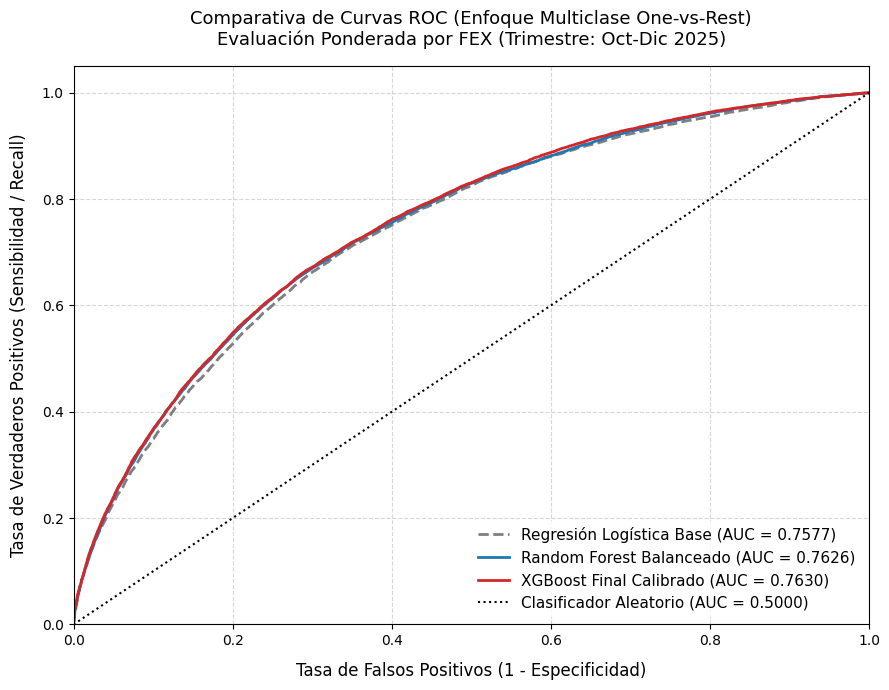

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# ==============================================================================
# 1. PREPARACIÓN DE LOS DATOS (Binarización Automática Multiclase OvR)
# ==============================================================================
# Extraemos dinámicamente las clases reales presentes en tu conjunto de prueba
clases_reales = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=clases_reales)
n_classes = y_test_bin.shape[1]

# CONFIGURACIÓN DEL LIENZO ACADÉMICO
plt.figure(figsize=(9, 7))
lw = 2  # Grosor de la línea

# ==============================================================================
# 2. CÁLCULO DE CURVAS ROC MACRO PARA CADA MODELO
# ==============================================================================
# Diccionario con tus matrices de probabilidad asignadas
modelos_prob = {
    'Regresión Logística Base (AUC = 0.7577)': y_prob_log,
    'Random Forest Balanceado (AUC = 0.7626)': y_prob_bal,
    'XGBoost Final Calibrado (AUC = 0.7630)': y_prob_final
}

colores = ['#7f7f7f', '#1f77b4', '#d62728']  # Gris para base, Azul y Rojo para ensambles
estilos = ['--', '-', '-']                    # Estilos de línea correctos para matplotlib

for (nombre, y_score), color, estilo in zip(modelos_prob.items(), colores, estilos):
    # Diccionarios locales para almacenar tasas por clase
    fpr = dict()
    tpr = dict()

    # Iterar sobre las clases binarizadas correctamente
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i], sample_weight=w_test)

    # Calcular la curva ROC agregada (Macro-average)
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    # CORREGIDO: Eliminado 'stroke_style' que causaba el quiebre del objeto Line2D
    plt.plot(all_fpr, mean_tpr, color=color, linestyle=estilo,
             label=nombre, linewidth=lw)

# ==============================================================================
# 3. ESTILIZACIÓN FINAL DE LA GRÁFICA PARA EL TFM
# ==============================================================================
# Línea de referencia del clasificador aleatorio
plt.plot([0, 1], [0, 1], color='black', linestyle=':', linewidth=1.5, label='Clasificador Aleatorio (AUC = 0.5000)')

# Ajustes de ejes y etiquetas normativas
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12, labelpad=10)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontsize=12, labelpad=10)
plt.title('Comparativa de Curvas ROC (Enfoque Multiclase One-vs-Rest)\nEvaluación Ponderada por FEX (Trimestre: Oct-Dic 2025)', fontsize=13, pad=15)

# Cuadrícula y leyenda integradas
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc="lower right", fontsize=11, frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Ejecutar renderizado
plt.show()